In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

In [4]:
test_df = pd.read_csv("Google_Stock_Price_Test.csv")
train_df = pd.read_csv("Google_Stock_Price_Train.csv")

In [5]:
train_df.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"


In [6]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1258 non-null   str    
 1   Open    1258 non-null   float64
 2   High    1258 non-null   float64
 3   Low     1258 non-null   float64
 4   Close   1258 non-null   str    
 5   Volume  1258 non-null   str    
dtypes: float64(3), str(3)
memory usage: 88.5 KB


In [7]:
train_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Open,1258.0,533.709833,151.904442,279.12,404.115,537.47,654.9225,816.68
High,1258.0,537.880223,153.008811,281.21,406.765,540.75,662.5875,816.68
Low,1258.0,529.007409,150.552807,277.22,401.765,532.99,644.8000,805.14


In [8]:
train_prices = train_df[['Open']].values

In [9]:
train_prices.shape

(1258, 1)

In [10]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_train_prices = scaler.fit_transform(train_prices)

In [11]:
X_train = []
y_train = []
timestamp = 60
for i in range(timestamp, len(train_prices)):
  X_train.append(scaled_train_prices[i-timestamp:i, 0])
  y_train.append(scaled_train_prices[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)
"""(samples, timesteps, features)
For stock prediction:
Samples = 1197
Timesteps = 60 (previous 60 days)
Features = 1 (only Open price)"""
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

In [15]:


model = Sequential()
model.add(LSTM(10, input_shape = (60, 1)))
model.add(Dense(1))


In [16]:
model.compile(optimizer='adam',loss='mean_squared_error')

In [17]:
model.fit(X_train , y_train,
          epochs = 50,
          batch_size = 1)

Epoch 1/50


1198/1198 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0170
Epoch 2/50
1198/1198 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 9.9007e-04
Epoch 3/50
1198/1198 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 8.8925e-04
Epoch 4/50
1198/1198 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 7.2585e-04
Epoch 5/50
1198/1198 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 6.5670e-04
Epoch 6/50
1198/1198 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 5.6529e-04
Epoch 7/50
1198/1198 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 5.0037e-04
Epoch 8/50
1198/1198 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 4.6629e-04
Epoch 9/50
1198/1198 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 4.0947e-04
Epoch 10/50
1198/1198 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 3.9732e-04
Epoch 11/50
1198/1198 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 3.6633e-04
Epoch 12/50
1198/1198 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 3.4546e-04
Epoch 13/50
1198/1198 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 3.3157e-04
Epoch 14/50
1198/1198 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss:

In [18]:
real_prices = test_df[['Open']].values

dataset_total = pd.concat(
    (train_df['Open'], test_df['Open']), axis=0
)
inputs = dataset_total[len(dataset_total) - len(test_df) - 60:].values
inputs = inputs.reshape(-1, 1)
inputs = scaler.transform(inputs)   # use the already-fitted scaler

X_test = []
for i in range(60, 80):   # 80 = 60 + 20 test days
    X_test.append(inputs[i - 60 : i, 0])

X_test = np.array(X_test).reshape(-1, 60, 1)

In [19]:
predicted_scaled = model.predict(X_test)
predicted_prices  = scaler.inverse_transform(predicted_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


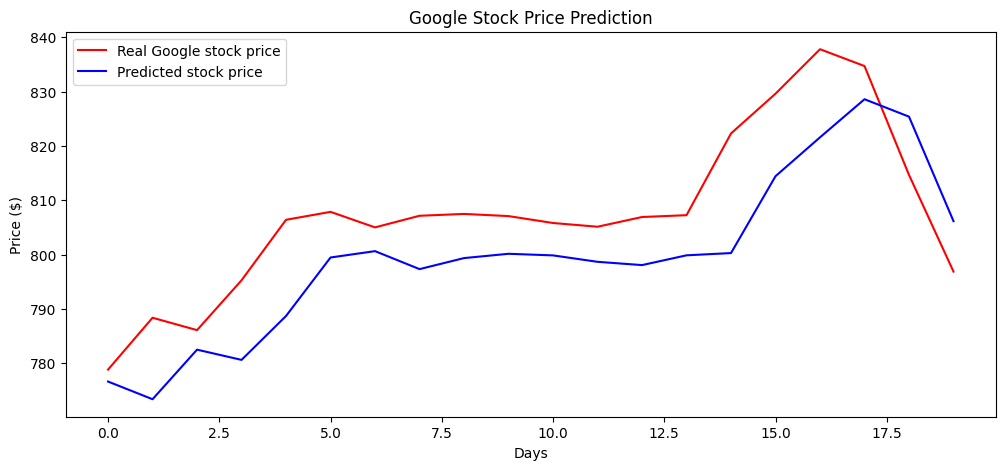

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(real_prices,      color='red',  label='Real Google stock price')
plt.plot(predicted_prices, color='blue', label='Predicted stock price')
plt.title('Google Stock Price Prediction')
plt.xlabel('Days'); plt.ylabel('Price ($)')
plt.legend()
plt.show()

In [21]:


# Inference function (moved here for execution)
def predict_stock_price(model, scaler, historical_prices):
    """
    Predicts the next stock price given a history of prices.

    Args:
        model: The trained Keras LSTM model.
        scaler: The MinMaxScaler used for training.
        historical_prices: A 1D numpy array or list of the last 60 stock prices (Open prices).

    Returns:
        The predicted next stock price.
    """
    # Ensure historical_prices is a numpy array and has the correct shape for scaling
    historical_prices = np.array(historical_prices).reshape(-1, 1)

    # Scale the input prices using the *already fitted* scaler
    scaled_prices = scaler.transform(historical_prices)

    # Reshape for the model: (batch_size, timesteps, features)
    # For a single prediction, batch_size = 1.
    # The model expects input samples of shape (timesteps, features), which is (60, 1).
    # So, for a single prediction, the input to predict should be (1, 60, 1).
    input_for_prediction = scaled_prices.reshape(1, len(historical_prices), 1)

    # Make prediction
    predicted_scaled_price = model.predict(input_for_prediction, verbose=0)

    # Inverse transform to get the actual price
    predicted_price = scaler.inverse_transform(predicted_scaled_price)

    return predicted_price[0][0]

# Get the last `timestamp` (60) days of 'Open' prices from the training data
historical_prices = train_prices[-timestamp:].flatten()

# Predict the next stock price
next_day_prediction = predict_stock_price(model, scaler, historical_prices)

print(f"Predicted stock price for the next day: ${next_day_prediction:.2f}")

Predicted stock price for the next day: $776.61


In [23]:
# Define the path to save the model
# Assuming the base path for your data is '/content/drive/MyDrive/Colab Notebooks/Google_stock_prediction(RNN_LSTM)/'
model_save_path = "stock_prediction_model.keras"

# Save the model
model.save(model_save_path)

print(f"Model saved successfully to: {model_save_path}")

Model saved successfully to: stock_prediction_model.keras
